In [1]:
import os

# Use conda's newer libstdc++ instead of the system one
conda_lib = os.path.expanduser("~/.conda/envs/hnn-core-env/lib")
ld_path = os.environ.get("LD_LIBRARY_PATH", "")
os.environ["LD_LIBRARY_PATH"] = f"{conda_lib}:{ld_path}"

# UCX settings (from before)
os.environ["UCX_TLS"] = "tcp,self,sm"
os.environ["UCX_NET_DEVICES"] = "all"


# MPI paths
mpi_bin = "/oscar/rt/sw/external/hpcx-mpi/2.25.1/bin"
mpi_lib = "/oscar/rt/sw/external/hpcx-mpi/2.25.1/lib"
if mpi_bin not in os.environ["PATH"]:
    os.environ["PATH"] = f"{mpi_bin}:{os.environ['PATH']}"
if mpi_lib not in ld_path:
    os.environ["LD_LIBRARY_PATH"] = f"{mpi_lib}:{os.environ['LD_LIBRARY_PATH']}"

import sys
# Add MPI bin directory to PATH
mpi_bin = "/oscar/rt/sw/external/hpcx-mpi/2.25.1/bin"
if mpi_bin not in os.environ["PATH"]:
    os.environ["PATH"] = f"{mpi_bin}:{os.environ['PATH']}"

# print("Updated PATH to include MPI")
# print("MPI location:", mpi_bin)

import os
print("PATH:", os.environ.get('PATH', 'NOT SET'))
print("Which mpiexec:")
import subprocess
result = subprocess.run(['which', 'mpiexec'], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else "mpiexec not found")

PATH: /oscar/rt/sw/external/hpcx-mpi/2.25.1/bin:/oscar/home/xgao35/venvs/hnn-core-calcium-202602/bin:/oscar/rt/9.6/25/x86_64_v3/code-server-4.96.4-2mbqypo7726gva5cbeogfppy2doijdhq/lib/vscode/bin/remote-cli:/users/xgao35/.pixi/bin:/users/xgao35/.conda/envs/hnn_core/bin:/oscar/runtime/bin:/oscar/rt/9.6/25/spack/x86_64_v3/code-server-4.96.4-2mbqypo7726gva5cbeogfppy2doijdhq/bin:/users/xgao35/.pixi/bin:/users/xgao35/miniconda3/bin:/users/xgao35/miniconda3/condabin:/users/xgao35/.conda/envs/hnn_core/bin:/usr/local/bin:/usr/bin:/usr/local/sbin:/usr/sbin:/usr/lpp/mmfs/bin:/usr/lpp/mmfs/sbin:/users/xgao35/bin:/users/xgao35/bin
Which mpiexec:
/oscar/rt/sw/external/hpcx-mpi/2.25.1/bin/mpiexec



In [2]:
import os.path as op

import matplotlib.pyplot as plt

from hnn_core import calcium_model, read_params, simulate_dipole, average_dipoles, read_dipole
from hnn_core.network_models import duecker_ET_model
from hnn_core.viz import plot_dipole
import matplotlib.pyplot as plt
from copy import deepcopy
import pandas as pd
import pickle
import numpy as np
from hnn_core import MPIBackend

--No graphics will be displayed.


In [3]:
import json
from hnn_core.hnn_io import read_network_configuration

# load BETA4 net (handtuned for now)
with open('/users/xgao35/Desktop/HNN_TEP/Networks/BETA4_100_calcium_202602_optim.pkl', 'rb') as f:
    TEP_net = pickle.load(f)

def scale_and_smooth(dpls, window_len=10, scaling_factor=0.3):
    dpls_smoothed = deepcopy(dpls)
    for dpl in dpls_smoothed:
        dpl.smooth(window_len).scale(scaling_factor)
    return dpls_smoothed
    from hnn_core.viz import plot_spikes_raster

In [4]:
def mean_rates(net,tstart,tstop, mean_type):
    spike_rates = dict()
    for cell_type in net.cell_response.cell_types:
            cell_type_gids = net.gid_ranges[cell_type]
            # cell_type_gids = np.array(gid_ranges[cell_type])
            n_trials, n_cells = len(net.cell_response.spike_types), len(cell_type_gids)
            gid_spike_rate = np.zeros((n_trials, n_cells))

            trial_data = zip(net.cell_response.spike_types, net.cell_response.spike_gids, net.cell_response.spike_times)
            for trial_idx, (spike_types, spike_gids, spike_times) in enumerate(trial_data):
                # adding the time constraints
                trial_type_mask = np.isin(spike_types, cell_type) & (np.array(spike_times) >= tstart) & (np.array(spike_times) <= tstop)
                gids, gid_counts = np.unique(np.array(
                    spike_gids)[trial_type_mask], return_counts=True)

                gid_spike_rate[trial_idx, np.isin(cell_type_gids, gids)] = (
                    gid_counts / (tstop - tstart)) * 1000

            if mean_type == 'all':
                spike_rates[cell_type] = np.mean(
                    gid_spike_rate.mean(axis=1))
            if mean_type == 'trial':
                spike_rates[cell_type] = np.mean(
                    gid_spike_rate, axis=1).tolist()
            if mean_type == 'cell':
                spike_rates[cell_type] = [gid_trial_rate.tolist()
                                          for gid_trial_rate in gid_spike_rate]

    return spike_rates


In [5]:
with MPIBackend(n_procs=3, mpi_cmd='mpiexec'):
    TEP_dpl = simulate_dipole(TEP_net, tstop=400, n_trials=3,bsl_cor='duecker')

MPI will run 3 trial(s) sequentially by distributing network neurons over 3 processes.
numprocs=3
Loading custom mechanism files from /oscar/home/xgao35/Desktop/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Building the NEURON model
Loading custom mechanism files from /oscar/home/xgao35/Desktop/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Loading custom mechanism files from /oscar/home/xgao35/Desktop/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
[Done]
Trial 1: 0.03 ms...
Trial 1: 10.0 ms...
Trial 1: 20.0 ms...
Trial 1: 30.0 ms...
Trial 1: 40.0 ms...
Trial 1: 50.0 ms...
Trial 1: 60.0 ms...
Trial 1: 70.0 ms...
Trial 1: 80.0 ms...
Trial 1: 90.0 ms...
Trial 1: 100.0 ms...
Trial 1: 110.0 ms...
Trial 1: 120.0 ms...
Trial 1: 130.0 ms...
Trial 1: 140.0 ms...
Trial 1: 150.0 ms...
Trial 1: 160.0 ms...
Trial 1: 170.0 ms...
Trial 1: 180.0 ms...
Trial 1: 190.0 ms...
Trial 1: 200.0 ms...
Trial 1: 210.0 ms...
Trial 1: 220.0 ms...
Trial 1: 230.0 ms...
Trial 1: 240.0 ms...
Trial 1: 250.0 ms...
Trial 1: 260.0 

In [65]:
def plot_spike_rates_line(net_list, tstop, cell_type, title_list, ylim=38):
    plt.figure(figsize=(10, 3)) 
    times = np.arange(-100, tstop, 5)
    plot_times = times + 100

    for i, net in enumerate(net_list):
        mean_spiking =[]
        sd_spiking =[]
        for j,t in enumerate(times):
            if j < len(times)-1:
                trial_rates = mean_rates(net, tstart=times[j], tstop=times[j+1],
                                                mean_type='trial')
                mean_spiking.append(np.mean(trial_rates[cell_type]))
                sd_spiking.append(np.std(trial_rates[cell_type]))
            
        # plt.errorbar(times[1:], mean_spiking, yerr=sd_spiking, label=title_list[i], fmt='-', capsize=5, color='r')
        plt.plot(times[1:], mean_spiking, color='r',linewidth=3)
    plt.legend(fontsize='large')
    plt.xlabel('Time (ms)')
    plt.ylabel('Firing rate (Hz)')
    plt.ylim(0,ylim)
    plt.xlim(-100, tstop)
    # plt.title(f'{cell_type} Firing Rate Over Time (BETA9)')
    plt.tight_layout()
    plt.axvline(0, color='r', linestyle='-', linewidth=2)

    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(4)
    ax.spines['bottom'].set_linewidth(4)
    ax.tick_params(width=4, length=10)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(4))

    plt.show()
    plt.savefig('Figures/L5_pyramidal_spiking.png')

/tmp/ipykernel_552973/729485537.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize='large')


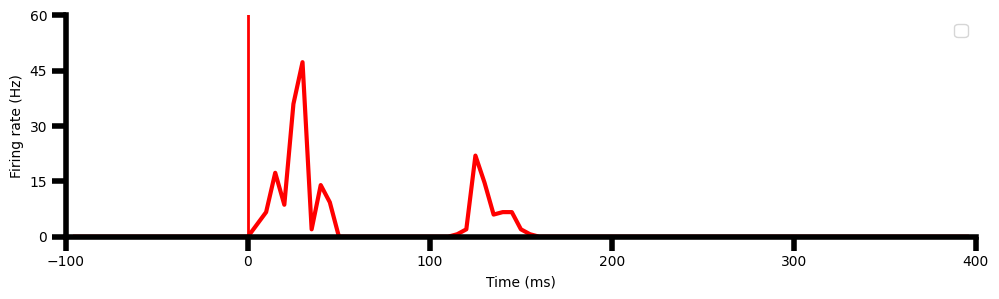

<Figure size 640x480 with 0 Axes>

In [66]:
plot_spike_rates_line([TEP_net], 400, 'L5_pyramidal', ['Simulated Firing Rate'], ylim=60)

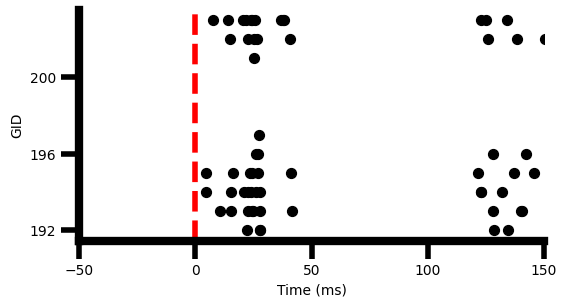

In [79]:
import matplotlib.ticker as ticker

net = TEP_net
l5_gids = net.gid_ranges['L5_pyramidal'][18:34]

# pull out only those spikes whose gid is in the L5 set
raster_t = []
raster_g = []
for trial_gids, trial_times in zip(net.cell_response.spike_gids,
                                   net.cell_response.spike_times):
    trial_gids = np.array(trial_gids)
    trial_times = np.array(trial_times)
    mask = np.isin(trial_gids, list(l5_gids))
    raster_t.extend(trial_times[mask].tolist())
    raster_g.extend(trial_gids[mask].tolist())

plt.figure(figsize=(6, 3))
plt.scatter(raster_t, raster_g, s=50,color='k')
plt.xlabel('Time (ms)')
plt.ylabel('GID')
plt.xlim(-50, 150)
plt.axvline(0, color='r', linestyle='--', linewidth=4)


ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(6)
ax.spines['bottom'].set_linewidth(6)
ax.tick_params(width=4, length=13)
ax.yaxis.set_major_locator(ticker.MaxNLocator(4))
ax.xaxis.set_major_locator(ticker.MaxNLocator(4))

plt.show()